# NLP-Themenextraktion aus Bürgerbeschwerden der Stadt Münster

**Kurs:** Projekt: Data Analysis (DLBDSEDA02), Aufgabe 1: NLP-Techniken auf eine Textsammlung anwenden.

**Ziel:** Aus den Freitext-Meldungen des Münsteraner *Mängelmelders* (Open311-Bürgeranliegen) die
häufigsten Beschwerde-Themen extrahieren, damit die Stadtverwaltung einen Überblick über die
drängendsten Bürgeranliegen bekommt.

**Pipeline:** 1) Laden & Sichten → 2) Vorverarbeitung → 3) Vektorisierung (BoW + TF-IDF) →
4) Kurzvergleich → 5) Themenmodelle (LSA + LDA) → 6) Darstellung & Diskussion.

**Datenquelle:** Stadt Münster / Beteiligung NRW, Open311-Schnittstelle. Lizenz: *Datenlizenz
Deutschland Namensnennung 2.0*. Die Meldungen wurden mit
`scripts/01_fetch_muenster_maengelmelder.py` gezogen und liegen lokal unter
`data/muenster_maengelmelder.csv`.

In [1]:
# Einmalig: NLTK-Ressourcen fuer die deutsche Vorverarbeitung laden
# (Satz-/Wort-Tokenizer + deutsche Stoppwortliste, Wortnormalisierung spaeter via SnowballStemmer).
import nltk
for paket in ["punkt", "punkt_tab", "stopwords"]:
    nltk.download(paket, quiet=True)

## 1. Daten laden und sichten

Zentrale Spalte fuer die Analyse ist der Freitext `description` (die eigentliche Beschwerde).
`service_name` ist die von der Stadt vergebene Kategorie. Sie dient uns spaeter als
Plausibilitaets-Check fuer die automatisch extrahierten Themen.

In [2]:
import pandas as pd
from pathlib import Path

CSV = Path("../data/muenster_maengelmelder.csv")
if not CSV.exists():
    raise FileNotFoundError(
        f"Datendatei fehlt: {CSV}\n"
        "Bitte zuerst den Datensatz beschaffen:\n"
        "    python scripts/01_fetch_muenster_maengelmelder.py"
    )

df = pd.read_csv(CSV)

print(f"Meldungen: {df.shape[0]}   Spalten: {df.shape[1]}")
print(f"Zeitraum : {df['requested_datetime'].min()[:10]}  bis  {df['requested_datetime'].max()[:10]}")
df.info()

Meldungen: 17659   Spalten: 10
Zeitraum : 2023-07-18  bis  2026-07-09
<class 'pandas.DataFrame'>
RangeIndex: 17659 entries, 0 to 17658
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   service_request_id  17659 non-null  int64  
 1   requested_datetime  17659 non-null  str    
 2   service_name        17659 non-null  str    
 3   status              17659 non-null  str    
 4   description         17659 non-null  str    
 5   address             17659 non-null  str    
 6   zipcode             17650 non-null  float64
 7   lat                 17659 non-null  float64
 8   long                17659 non-null  float64
 9   status_notes        13808 non-null  str    
dtypes: float64(3), int64(1), str(6)
memory usage: 1.3 MB


In [3]:
# Worueber wird gemeldet? Staedtische Kategorien (spaeter Abgleich mit den NLP-Themen)
print("Top-15 Kategorien (service_name):")
print(df["service_name"].value_counts().head(15).to_string())

# Laenge der Freitext-Beschreibungen in Woertern
wortzahl = df["description"].fillna("").str.split().str.len()
print("\nFreitext-Laenge (Woerter):")
print(wortzahl.describe().round(1).to_string())

# Datenqualitaet: gibt es Meldungen ganz ohne Text?
anzahl_leer = (df["description"].fillna("").str.strip() == "").sum()
print("leere Beschreibungen:", int(anzahl_leer))

Top-15 Kategorien (service_name):
service_name
Illegale Abfallablagerung                5204
Straße                                   1308
Gehweg                                   1285
Beleuchtung                              1160
Schrottfahrrad                           1043
Fahrradweg                                868
Baum                                      865
Verunreinigung                            823
Ampel                                     816
Grünanlage                                808
Verkehrsschild                            738
Kanalisation                              730
Elektrogeräte                             497
Glas-/Elektroschrottcontainerstandort     460
Spielplatz                                422

Freitext-Laenge (Woerter):


count    17659.0
mean        25.9
std         18.9
min          1.0
25%         12.0
50%         20.0
75%         36.0
max         86.0
leere Beschreibungen: 0


In [4]:
# Drei echte Beispiel-Beschwerden ansehen (gekuerzt auf die ersten 300 Zeichen)
for text in df["description"].dropna().head(3):
    einzeile = " ".join(str(text).split())
    print("-", einzeile[:300], "\n")

- Das Signal über der Fahrbahn ist aus der Entfernung nicht frühzeitig zu erkennen; wird aufgrund des Straßenverlaufs und einem der entlang der Straße gepflanzten Bäume aufgrund seiner Größe vollständig verdeckt. 

- Liebe Stadt Münster, nachdem sich nach meiner ersten Meldung (siehe Bild im Anhang) nichts geändert hat, hier mein zweiter Versuch. Es liegen nach wie vor starke Verunreinigungen seit Monaten vor unserer Haustür an der Friedrich-Ebert-Str. 14 vor. 

- Sehr geehrte Damen und Herren, wie auf dem angehängten Bild ersichtlich, ist einer der Ampeln vermutlich mutwillig beschädigt worden. Viele der anderen Ampeln an der Kreuzung haben abgeschlagene Sonnenblenden. Vielen Dank! Mit freundlichen Grüßen 



## 2. Vorverarbeitung (saubere Texte)

Kleinschreibung, URLs/Zahlen/Sonderzeichen entfernen (`re`, Umlaute bleiben erhalten),
Tokenisierung und deutsche Stoppwoerter (`nltk`), Wortnormalisierung via
`SnowballStemmer('german')` (Kursbuch-Rahmen, `WordNetLemmatizer` ist englisch-only).

In [5]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

# Deutsche Stoppwoerter (nltk) + eigene Ergaenzungen: Woerter, die in fast jeder Meldung
# vorkommen, aber kein Thema tragen (Hoeflichkeitsfloskeln, Ortsname, Behoerdenanrede).
# Nach einem ersten Blick auf die Themen um weitere Floskeln ergaenzt.
STOPWORTS = set(stopwords.words("german"))
STOPWORTS.update([
    "stadt", "münster", "bitte", "danke", "dank", "hallo", "guten", "tag",
    "sehr", "geehrte", "geehrter", "damen", "herren", "liebe",
    "gruß", "grüße", "grüßen", "gruss", "freundlichen",
    "liegt", "liegen", "steht", "stehen", "siehe", "foto", "woche", "wochen",
    "schon", "mehr", "immer", "bereits", "seit", "wurde", "ca",
])
stemmer = SnowballStemmer("german")

def preprocess_de(text):
    """Deutsche Textwaesche: klein -> URLs/Zahlen/Satzzeichen weg (Umlaute bleiben)
    -> Tokenisierung -> Stoppwoerter/Kurz-Tokens raus -> Stemming."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # URLs entfernen
    text = re.sub(r"[^a-zäöüß\s]", " ", text)          # nur Buchstaben + Leerzeichen (ä/ö/ü/ß bleiben)
    tokens = word_tokenize(text, language="german")
    tokens = [t for t in tokens if t not in STOPWORTS and len(t) > 2]
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

df["clean"] = df["description"].apply(preprocess_de)
print("Vorverarbeitung fertig fuer", len(df), "Meldungen.")

Vorverarbeitung fertig fuer 17659 Meldungen.


In [6]:
# Kontrolle: Vorher/Nachher an einem Beispiel + Kennzahlen
beispiel_nr = 1
print("VORHER :", " ".join(str(df["description"].iloc[beispiel_nr]).split())[:200])
print("NACHHER:", df["clean"].iloc[beispiel_nr][:200])

# Wie viele Meldungen sind nach der Bereinigung leer?
anzahl_leer = (df["clean"].str.strip() == "").sum()
print("\nleer nach Bereinigung:", int(anzahl_leer))

# Vokabular: alle unterschiedlichen Wortstaemme des Korpus einsammeln
vokabular = set()
for text in df["clean"]:
    vokabular.update(text.split())
print("Vokabular (unterschiedliche Wortstaemme):", len(vokabular))

# Wie viele Staemme bleiben je Meldung uebrig?
laenge = df["clean"].str.split().str.len()
print(f"Tokens je Dokument: Median {int(laenge.median())}, Mittel {laenge.mean():.1f}")

VORHER : Liebe Stadt Münster, nachdem sich nach meiner ersten Meldung (siehe Bild im Anhang) nichts geändert hat, hier mein zweiter Versuch. Es liegen nach wie vor starke Verunreinigungen seit Monaten vor unse
NACHHER: nachd erst meldung bild anhang geandert zweit versuch stark verunrein monat uns haustur friedrich ebert str

leer nach Bereinigung: 71
Vokabular (unterschiedliche Wortstaemme): 20462


Tokens je Dokument: Median 10, Mittel 12.7


## 3. Vektorisierung (2 Verfahren)

Bag-of-Words (`CountVectorizer`) und TF-IDF (`TfidfVectorizer`) aus `scikit-learn`.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Nur nicht-leere bereinigte Texte modellieren (nach der Bereinigung leer gewordene raus,
# die Anzahl steht im Kontroll-Output von Schritt 2)
hat_text = df["clean"].str.strip() != ""
docs = df.loc[hat_text, "clean"]
print("Dokumente fuer die Modellierung:", len(docs))

# Gemeinsame Einstellungen EINMAL definieren, damit beide Vektorisierer garantiert
# identisch arbeiten (gleiches Vokabular -> fairer Vergleich):
# sehr seltene Terme raus (min_df=5), Einzelwoerter + Bigramme.
VEC_KW = dict(min_df=5, ngram_range=(1, 2))

# Bag-of-Words (reine Zaehlungen) -> spaeter Grundlage fuer LDA
count_vectorizer = CountVectorizer(**VEC_KW)
X_counts = count_vectorizer.fit_transform(docs)

# TF-IDF (haeufig UND charakteristisch gewichtet) -> spaeter Grundlage fuer LSA
tfidf_vectorizer = TfidfVectorizer(**VEC_KW)
X_tfidf = tfidf_vectorizer.fit_transform(docs)

print("BoW-Matrix   :", X_counts.shape)
print("TF-IDF-Matrix:", X_tfidf.shape)
print("Vokabular (Terme nach min_df):", len(count_vectorizer.get_feature_names_out()))

Dokumente fuer die Modellierung: 17588


BoW-Matrix   : (17588, 8101)
TF-IDF-Matrix: (17588, 8101)
Vokabular (Terme nach min_df): 8101


## 4. Kurzvergleich der Vektorisierungen

Top-Terme je Verfahren gegenueberstellen (Haeufigkeit bei BoW vs. hoechste TF-IDF-Gewichte):
welche Repraesentation hebt themenspezifische Woerter staerker hervor?

In [8]:
import numpy as np

features = count_vectorizer.get_feature_names_out()   # bei beiden Vektorisierern identisch

# BoW: haeufigste Terme (Summe der Zaehlungen ueber alle Dokumente)
bow_sums = np.asarray(X_counts.sum(axis=0)).ravel()
reihenfolge_bow = bow_sums.argsort()[::-1]        # Spalten-Indizes, groesster Wert zuerst
top_bow = [features[i] for i in reihenfolge_bow[:15]]

# TF-IDF: Terme mit hoechstem durchschnittlichem Gewicht
tfidf_means = np.asarray(X_tfidf.mean(axis=0)).ravel()
reihenfolge_tfidf = tfidf_means.argsort()[::-1]
top_tfidf = [features[i] for i in reihenfolge_tfidf[:15]]

vergleich = pd.DataFrame({"BoW (haeufigste)": top_bow, "TF-IDF (hoechstes Gewicht)": top_tfidf})
print("Top-15 Terme je Verfahren:\n")
print(vergleich.to_string(index=False))

Top-15 Terme je Verfahren:

BoW (haeufigste) TF-IDF (hoechstes Gewicht)
          strass                     strass
            mull                       mull
          gehweg                     gehweg
            viel                       viel
             hoh                        hoh
            haus                       haus
           gross                  sperrmull
            baum                        eck
       sperrmull                      gross
             eck                     defekt
            mehr                       baum
            leid                       mehr
          radweg                     radweg
        richtung                       leid
          gefahr                       wurd


**Kurzes Fazit des Vergleichs:** Beide Listen beginnen fast identisch, weil strass, mull und gehweg
den Korpus dominieren. Der Unterschied zeigt sich dahinter: TF-IDF hebt charakteristische Wörter wie
sperrmull und defekt nach oben, während generische Wörter wie richtung zurückfallen. Beide
Repräsentationen sind für die Themenextraktion brauchbar, TF-IDF betont themenspezifische Begriffe
aber sichtbar stärker.

## 5. Themenextraktion (2 Verfahren)

Zwei Verfahren: LDA (`LatentDirichletAllocation`) auf den BoW-Zaehlungen (probabilistisch) und LSA
(`TruncatedSVD`) auf der TF-IDF-Matrix (SVD-basiert). LDA erhaelt bewusst die rohen Zaehlungen statt
TF-IDF-Gewichten, denn das Modell beschreibt das Entstehen von Worthaeufigkeiten je Thema.
Umgewichtete Werte wuerden diese Annahme verletzen. LSA arbeitet dagegen auf der TF-IDF-Matrix,
weil die SVD dort von der Hervorhebung charakteristischer Terme profitiert. Hinweis: LSA-Komponenten
koennen negativ sein, daher werden die Top-Woerter ueber den Betrag der Ladung bestimmt.

### 5.1 Wahl der Themenzahl k (erprobt mit LDA)

Die Themenzahl `k` ist ein Parameter, den beide Verfahren brauchen. Erprobt wird sie hier mit LDA,
also dem Verfahren, dessen Themen am Ende inhaltlich gedeutet werden. Wir vergleichen mehrere Werte
nach zwei Kriterien: der Interpretierbarkeit der Themen (Top-Woerter
je Thema) und der Themenkohaerenz als nachrechenbarer Kennzahl. Die Kennzahl misst, wie oft die
wichtigsten Woerter eines Themas gemeinsam in denselben Meldungen stehen (UMass-Variante, ausfuehrlich
in 5.4). Je naeher der Wert an 0 liegt, desto besser. Der gewaehlte Wert gilt anschliessend in 5.2
fuer beide Modelle.

In [9]:
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

# --- GEMEINSAME Hilfsfunktion: wird spaeter fuer LDA UND LSA benutzt ---
def top_woerter(components, feature_names, n=10):
    """Je Komponente die n staerksten Woerter (ueber |Ladung|, da LSA negativ sein kann)."""
    ergebnis = []
    for komponente in components:
        staerkste = np.abs(komponente).argsort()[::-1][:n]   # Indizes der n groessten Betraege
        woerter = [feature_names[i] for i in staerkste]
        ergebnis.append(woerter)
    return ergebnis

# --- Kennzahl: Themenkohaerenz (UMass) je Thema, Formel je Wortpaar ---
# log( (gemeinsame Meldungen + 1) / Meldungen mit dem Vergleichswort )
TOP_N = 10
dokument_hat_wort = (X_counts > 0)                       # kommt das Wort in der Meldung vor?

def themenkohaerenz(komponenten, top_n=TOP_N):
    """Je Thema ein Wert. Naeher an 0 heisst: die Top-Woerter stehen oefter gemeinsam."""
    werte = []
    for komponente in komponenten:
        top_indizes = np.abs(komponente).argsort()[::-1][:top_n]
        vorkommen = dokument_hat_wort[:, top_indizes].toarray()
        dokumentfrequenz = vorkommen.sum(axis=0)         # in wie vielen Meldungen steht jedes Wort?
        kohaerenz = 0.0
        for i in range(1, top_n):
            for j in range(i):
                gemeinsam = np.logical_and(vorkommen[:, i], vorkommen[:, j]).sum()
                kohaerenz = kohaerenz + np.log((gemeinsam + 1) / dokumentfrequenz[j])
        werte.append(kohaerenz)
    return werte

# --- LDA: mehrere Themenzahlen erproben, Top-Woerter ansehen UND die Kennzahl rechnen ---
lda_modelle = {}
kohaerenz_je_k = {}
for k in (5, 8, 12):
    modell = LatentDirichletAllocation(n_components=k, random_state=0, learning_method="batch")
    modell.fit(X_counts)
    lda_modelle[k] = modell
    kohaerenz_werte = themenkohaerenz(modell.components_)
    kohaerenz_je_k[k] = (np.mean(kohaerenz_werte), min(kohaerenz_werte))
    print(f"----- k = {k} Themen -----")
    themen = top_woerter(modell.components_, features, n=8)
    for nr, woerter in enumerate(themen, 1):
        print(f"  Thema {nr}: " + ", ".join(woerter))
    print(f"  Themenkohaerenz: Mittel {np.mean(kohaerenz_werte):.1f}, "
          f"schwaechstes Thema {min(kohaerenz_werte):.1f}")
    print()

# Der Mittelwert sagt, wie gut die Themen im Schnitt sind, das schwaechste Thema zeigt,
# wie weit das Modell nach unten ausreisst. Beides gehoert zur Wahl von k.
print("Themenkohaerenz je Themenzahl (0 = bester Wert):")
for k, (mittel, schwaechstes) in kohaerenz_je_k.items():
    print(f"  k = {k:2d}: Mittel {mittel:8.1f}   schwaechstes Thema {schwaechstes:8.1f}")

----- k = 5 Themen -----
  Thema 1: mull, sperrmull, entsorgt, haus, illegal, wurd, abgelegt, eck
  Thema 2: strass, viel, gefahr, radweg, fahrrad, defekt, hoh, schlagloch
  Thema 3: strass, ampel, hoh, recht, richtung, kreuzung, schild, link
  Thema 4: strass, ratt, gehweg, str, stell, bereich, tag, eck
  Thema 5: baum, gehweg, ast, viel, war, spielplatz, gross, grundstuck
  Themenkohaerenz: Mittel -121.5, schwaechstes Thema -128.5



----- k = 8 Themen -----
  Thema 1: entsorgt, wurd, mullsack, mull, sack, strass, gegenub, zwei
  Thema 2: strass, radweg, gefahr, viel, schlagloch, radfahr, hoh, gross
  Thema 3: ampel, recht, hoh, richtung, kreuzung, link, defekt, strass
  Thema 4: strass, str, stell, kreuzung, warendorf, eck, mehr, mecklenbeck
  Thema 5: baum, ast, gross, war, gehweg, viel, grundstuck, spielplatz
  Thema 6: gehweg, haus, fahrrad, schrottrad, rad, jahr, monat, mehr
  Thema 7: strass, ratt, latern, viel, wass, verstopft, hoh, heut
  Thema 8: mull, sperrmull, viel, illegal, leid, abgelegt, haus, entsorg
  Themenkohaerenz: Mittel -126.4, schwaechstes Thema -146.9



----- k = 12 Themen -----
  Thema 1: word, meldung, strass, gemeldet, mal, wurd, zwei, leid
  Thema 2: gefahr, strass, schlagloch, radweg, radfahr, viel, gross, stark
  Thema 3: ampel, hoh, defekt, kreuzung, ausgefall, grun, funktioniert, strass
  Thema 4: strass, kreuzung, str, richtung, wolbeck, ring, eck, hoh
  Thema 5: baum, ast, gehweg, grundstuck, gross, strauch, stark, war
  Thema 6: gehweg, fahrrad, haus, schrottrad, schrottfahrrad, rad, jahr, monat
  Thema 7: strass, ratt, latern, wass, verstopft, hoh, viel, defekt
  Thema 8: sperrmull, mull, viel, leid, entsorg, strass, stell, abgeholt
  Thema 9: bereich, strass, viel, gehweg, radweg, stell, mehr, kind
  Thema 10: mull, sperrmull, illegal, entsorgt, haus, neb, abgelegt, contain
  Thema 11: str, zeit, war, mulleim, schon, lang, eck, viel
  Thema 12: recht, link, mullsack, mull, strass, seit, richtung, grab
  Themenkohaerenz: Mittel -128.2, schwaechstes Thema -164.4

Themenkohaerenz je Themenzahl (0 = bester Wert):
  k =  5: Mi

### 5.2 Finale Themen mit k = 8 (LDA und LSA)

Die beiden Kriterien aus 5.1 zeigen nicht in dieselbe Richtung. Die Kennzahl spricht knapp fuer
k = 5 (-121.5 gegenueber -126.4 bei k = 8), der Abstand ist mit rund 4 Prozent aber klein. Dazu kommt
eine bekannte Eigenschaft der UMass-Kohaerenz: Sie bevorzugt wenige Themen, weil dann mehr
Allerweltswoerter wie strass oder gehweg in jedem Thema landen und die naturgemaess oft gemeinsam
vorkommen. Inhaltlich ist k = 5 zu grob. Dort gehen die Schrottraeder in einem grossen Strassen- und
Fahrrad-Thema unter, obwohl die staedtische Kategorie Schrottfahrrad mit 1.043 Meldungen die
fuenftgroesste ist. k = 12 zersplittert dagegen: Muell verteilt sich auf drei Themen, ein weiteres
Thema besteht nur noch aus Wiederholungsmeldungen, und das schwaechste Thema faellt auf -164.4.
Gewaehlt wird **k = 8** als Mitte aus Kennzahl und Trennschaerfe. Mit diesem Wert werden jetzt beide
Modelle ausgegeben: das bereits trainierte LDA und das frisch trainierte LSA.

In [10]:
K = 8

# --- Themenmodell 1: LDA (auf den BoW-Zaehlungen X_counts) ---
lda = lda_modelle[K]                         # das bereits trainierte k=8-Modell wiederverwenden

# --- Themenmodell 2: LSA (auf der TF-IDF-Matrix X_tfidf) ---
lsa = TruncatedSVD(n_components=K, random_state=0).fit(X_tfidf)

# --- Gemeinsame Ausgabe: dieselbe Funktion top_woerter fuer beide Modelle ---
print(f"=== LDA: {K} Themen (auf BoW-Zaehlungen) ===")
for nr, woerter in enumerate(top_woerter(lda.components_, features, n=10), 1):
    print(f"Thema {nr}: " + ", ".join(woerter))

print(f"\n=== LSA: {K} Themen (auf TF-IDF) ===")
for nr, woerter in enumerate(top_woerter(lsa.components_, features, n=10), 1):
    print(f"Thema {nr}: " + ", ".join(woerter))

=== LDA: 8 Themen (auf BoW-Zaehlungen) ===
Thema 1: entsorgt, wurd, mullsack, mull, sack, strass, gegenub, zwei, mehr, word
Thema 2: strass, radweg, gefahr, viel, schlagloch, radfahr, hoh, gross, richtung, stark
Thema 3: ampel, recht, hoh, richtung, kreuzung, link, defekt, strass, grun, seit
Thema 4: strass, str, stell, kreuzung, warendorf, eck, mehr, mecklenbeck, wolbeck, bereich
Thema 5: baum, ast, gross, war, gehweg, viel, grundstuck, spielplatz, stark, weit
Thema 6: gehweg, haus, fahrrad, schrottrad, rad, jahr, monat, mehr, schrottfahrrad, schild
Thema 7: strass, ratt, latern, viel, wass, verstopft, hoh, heut, defekt, gehweg
Thema 8: mull, sperrmull, viel, illegal, leid, abgelegt, haus, entsorg, kuhlschrank, eck

=== LSA: 8 Themen (auf TF-IDF) ===
Thema 1: strass, mull, gehweg, sperrmull, viel, haus, hoh, gross, eck, baum
Thema 2: mull, defekt, sperrmull, strass, latern, illegal, hoh, entsorgt, strassenlatern, ampel
Thema 3: defekt, latern, mull, gehweg, strassenlatern, baum, leuch

### 5.3 Abgleich mit den amtlichen Kategorien

Die Stadt vergibt zu jeder Meldung selbst eine Kategorie (`service_name`), die nicht in die Modelle
eingeflossen ist. Als Plausibilitäts-Check stellen wir die häufigsten Kategorien noch einmal neben
die LDA-Themen aus 5.2: Tauchen die großen Kategorien in den gefundenen Themen wieder auf?
Die Einordnung dazu steht in der Diskussion unter Punkt 6.

In [11]:
# Plausibilitaets-Check per Auge: die haeufigsten amtlichen Kategorien zum Vergleich
# mit den LDA-Themen aus 5.2 (service_name war kein Modell-Input).
# Zehn Zeilen, damit auch die in der Diskussion genannte Kategorie Ampel sichtbar ist.
print("Haeufigste amtliche Kategorien:")
print(df["service_name"].value_counts().head(10).to_string())

Haeufigste amtliche Kategorien:
service_name
Illegale Abfallablagerung    5204
Straße                       1308
Gehweg                       1285
Beleuchtung                  1160
Schrottfahrrad               1043
Fahrradweg                    868
Baum                          865
Verunreinigung                823
Ampel                         816
Grünanlage                    808


### 5.4 Themenkohärenz als Kennzahl

Dieselbe **Themenkohärenz**, die in 5.1 über die Themenzahl mitentschieden hat, wird hier für das
gewählte Modell einzeln je Thema ausgewiesen. Berechnet wird die einfache UMass-Variante, weil sie
ohne Zusatzpaket auskommt. Sie zählt in
den eigenen Meldungen, wie oft zwei Top-Wörter eines Themas gemeinsam in derselben Meldung stehen.
Je näher der Wert an 0 liegt, desto häufiger treten die Wörter zusammen auf. Stark negative Werte
bedeuten, dass die Wortliste eher zusammengewürfelt ist.

In [12]:
# Kennzahl je Thema fuer das gewaehlte Modell, mit der Funktion aus 5.1
kohaerenz_je_thema = themenkohaerenz(lda.components_)

print("UMass-Themenkohaerenz je LDA-Thema (Top-10 Woerter, 0 = bester Wert):")
reihenfolge_kohaerenz = np.argsort(kohaerenz_je_thema)[::-1]
themen_kurz = top_woerter(lda.components_, features, n=5)
for thema_index in reihenfolge_kohaerenz:
    print(f"  Thema {thema_index + 1}: {kohaerenz_je_thema[thema_index]:8.1f}   "
          + ", ".join(themen_kurz[thema_index]))

UMass-Themenkohaerenz je LDA-Thema (Top-10 Woerter, 0 = bester Wert):
  Thema 3:   -106.5   ampel, recht, hoh, richtung, kreuzung
  Thema 2:   -107.0   strass, radweg, gefahr, viel, schlagloch
  Thema 5:   -120.3   baum, ast, gross, war, gehweg
  Thema 8:   -122.9   mull, sperrmull, viel, illegal, leid
  Thema 1:   -124.3   entsorgt, wurd, mullsack, mull, sack
  Thema 6:   -139.5   gehweg, haus, fahrrad, schrottrad, rad
  Thema 7:   -144.2   strass, ratt, latern, viel, wass
  Thema 4:   -146.9   strass, str, stell, kreuzung, warendorf


Das Ergebnis stützt die qualitative Einschätzung aus 5.2 an den Rändern: Die am klarsten
benennbaren Themen erreichen die besten Werte (Thema 3 Ampeln, Thema 2 Straße/Radweg,
Thema 5 Bäume), das diffuse Thema 4 mit seinen Orts- und Straßennamen (warendorf, mecklenbeck) den
schwächsten. Im Mittelfeld ist die Kennzahl mit Vorsicht zu lesen: sehr häufige
Allerweltswörter (strass, gehweg) lassen einzelne Themen besser dastehen, weil sie in vielen
Meldungen gemeinsam stehen. Die Kennzahl ergänzt die qualitative Prüfung also, ersetzt sie aber nicht.

## 6. Darstellung & Diskussion

Top-Woerter je Thema als Balkendiagramm (`matplotlib`). Kurze Interpretation: welche Themen,
passen sie zu den staedtischen Kategorien, wo hakt es?

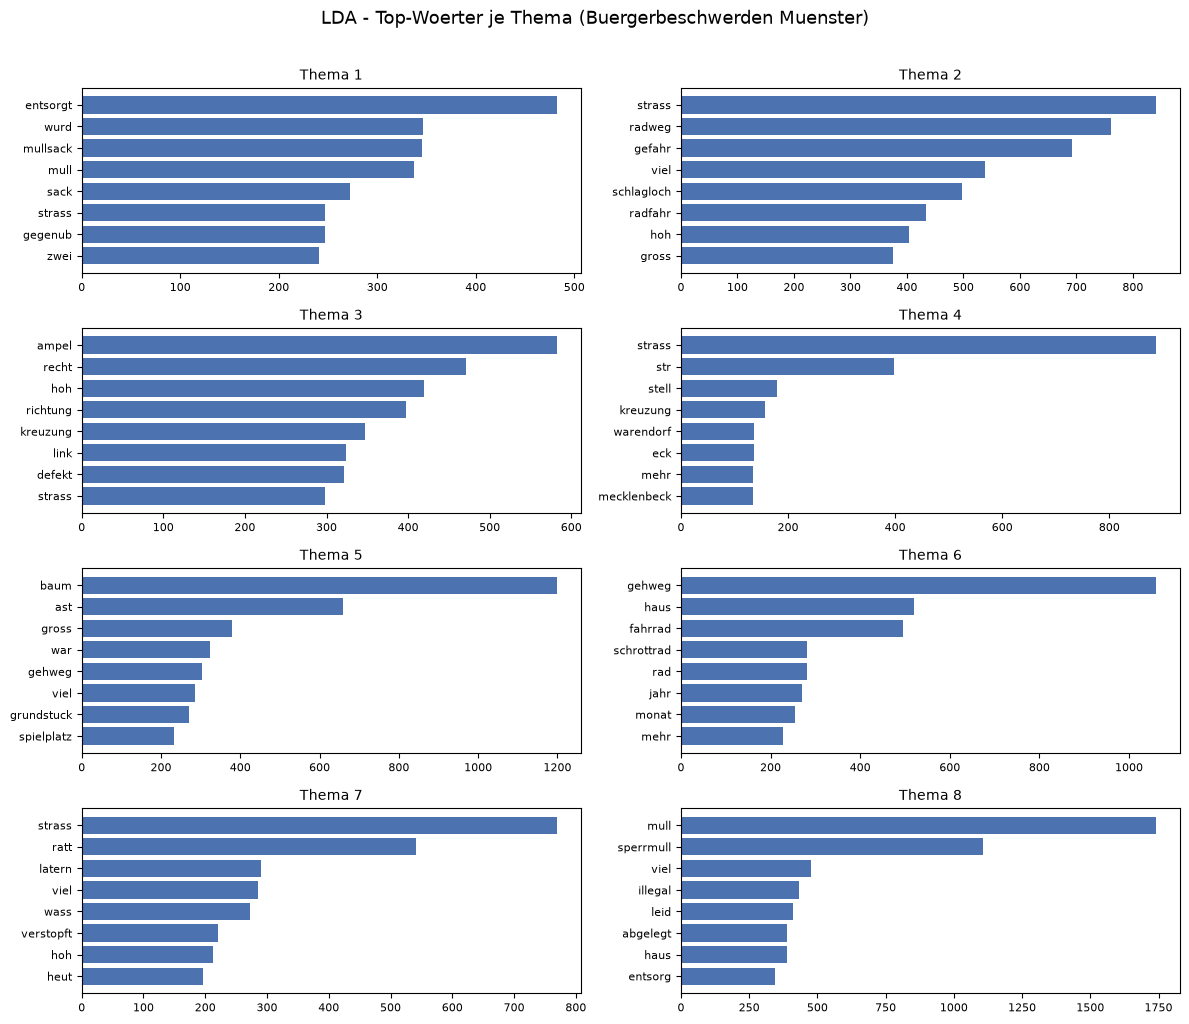

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt

def plot_themen(model, feature_names, titel, n=8):
    # Raster mit 2 Spalten, ein kleines Diagramm je Thema.
    # Die Zeilenzahl folgt aus der Themenzahl des Modells (hier: 8 Themen -> 4x2).
    anzahl_themen = model.n_components
    zeilen = anzahl_themen // 2
    fig, axes = plt.subplots(zeilen, 2, figsize=(12, 2.6 * zeilen))
    axes = axes.ravel()                      # das Gitter als einfache Liste 0..7
    for nr, komponente in enumerate(model.components_):
        staerkste = np.abs(komponente).argsort()[::-1][:n]
        woerter = [feature_names[i] for i in staerkste]
        gewichte = np.abs(komponente[staerkste])
        # Reihenfolge umdrehen, damit das staerkste Wort im Diagramm OBEN steht
        woerter = woerter[::-1]
        gewichte = gewichte[::-1]
        axes[nr].barh(woerter, gewichte, color="#4C72B0")
        axes[nr].set_title(f"Thema {nr + 1}", fontsize=10)
        axes[nr].tick_params(labelsize=8)
    fig.suptitle(titel, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

plot_themen(lda, features, "LDA - Top-Woerter je Thema (Buergerbeschwerden Muenster)")

### Diskussion

**Welche Themen kamen heraus?** Das LDA-Modell (k = 8) findet mehrere gut benennbare Beschwerde-Bereiche:
illegale Müllentsorgung prägt gleich zwei Themen: Müllsäcke und wilde Entsorgung (Thema 1) sowie
Sperrmüll und illegale Ablagerungen (Thema 8). Weiter erkennbar sind Gefahrenstellen auf Straßen und Radwegen
wie Schlaglöcher (Thema 2), Ampeln und Kreuzungen (Thema 3), Bäume und Äste (Thema 5) sowie
Schrotträder (Thema 6). Thema 7 mischt Ratten-, Laternen- und Wassermeldungen. Thema 4 bleibt diffus,
dort sammeln sich Orts- und Straßennamen (warendorf, mecklenbeck) und allgemeine Lageangaben, wie sie
in fast jeder Meldung vorkommen. Der dominierende Beschwerdegrund ist eindeutig die **illegale
Müllentsorgung**, sie prägt zwei der acht Themen. Die Themenkohärenz aus 5.4 stützt dieses Bild an den
Rändern: die klar benennbaren Themen liegen vorn, das diffuse Thema 4 bildet das Schlusslicht.

**Passen die Themen zu den amtlichen Kategorien?** Der Blick auf 5.3 zeigt: in den Kernen ja. Die mit
Abstand größte Kategorie „Illegale Abfallablagerung“ (5.204 Meldungen) spiegelt sich deutlich in den
Themen 1 und 8, „Schrottfahrrad“ in Thema 6, „Ampel“ in Thema 3 und „Baum“ in Thema 5, während
„Beleuchtung“ (Straßenlaternen) sich mit den Rattenmeldungen in Thema 7 mischt. Eine 1:1-Zuordnung
entsteht aber nicht: Die Verwaltungstaxonomie ist feiner als k = 8 (Straße,
Gehweg und Fahrradweg sind dort getrennte Kategorien), und die sehr häufige Müll-Kategorie färbt mehrere
Themen mit. Die unüberwacht gefundenen Themen ordnen die Beschwerden also gröber und teils anders als
die amtliche Einteilung.

**Vergleich der Verfahren.** LDA (auf den BoW-Zählungen) liefert die besser interpretierbaren Themen.
Die LSA-Komponenten (`TruncatedSVD` auf TF-IDF) überlappen stark, mull/strass/gehweg tauchen fast überall
auf, und die erste Komponente entspricht ungefähr dem Korpus-Durchschnitt. Für die *interpretierbare*
Themenübersicht ist LDA hier überlegen.

**Grenzen & Ausblick.** (1) Trotz der erweiterten Stoppwortliste stehen weiterhin Füllwörter in den
Themen (viel, hoh, gross, wurd) und Richtungswörter (recht, link), die Liste müsste iterativ weiter
ausgebaut werden. (2) Der `SnowballStemmer` macht Wörter schwerer lesbar (mull, latern statt Müll,
Laterne). (3) Die Themenzahl k = 8 stützt sich auf zwei Kriterien, die nicht in dieselbe Richtung zeigen: Die
Themenkohärenz aus 5.1 bevorzugt knapp k = 5, die inhaltliche Trennschärfe spricht für k = 8. Die
Kennzahl grenzt den sinnvollen Bereich also ein, entscheidet ihn aber nicht allein.
Weiterentwicklung: Stoppwortliste systematisch erweitern, feinere Abstufungen von k prüfen und ggf.
Lemmatisierung für lesbarere Themenwörter.